<a href="https://colab.research.google.com/github/Srinivaas-only/Banking-Campaign-Data-Analysis/blob/main/Banking_System_Analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [33]:
#Importing necessary libraries
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [34]:
#Import csv file (read it)
df = pd.read_csv('/content/banking_data.csv')

In [35]:
#Lets see if the file is correct by checking row and column
df.shape

(45216, 19)

In [36]:
df.head(-1)

,age,job,marital,marital_status,education,default,balance,housing,loan,contact,day,month,day_month,duration,campaign,pdays,previous,poutcome,y
0,58,management,married,married,tertiary,no,2143,yes,no,unknown,5,may,5-May,261,1,-1,0,unknown,no
1,44,technician,single,single,secondary,no,29,yes,no,unknown,5,may,5-May,151,1,-1,0,unknown,no
2,33,entrepreneur,married,married,secondary,no,2,yes,yes,unknown,5,may,5-May,76,1,-1,0,unknown,no
3,47,blue-collar,married,married,unknown,no,1506,yes,no,unknown,5,may,5-May,92,1,-1,0,unknown,no
4,33,unknown,single,single,unknown,no,1,no,no,unknown,5,may,5-May,198,1,-1,0,unknown,no
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
45210,37,entrepreneur,married,married,secondary,no,2971,no,no,cellular,17,nov,17-Nov,361,2,188,11,other,no
45211,29,management,single,single,tertiary,no,765,no,no,cellular,16,nov,16-Nov,238,1,-1,0,unknown,yes
45212,68,retired,married,married,secondary,no,1146,no,no,cellular,16,nov,16-Nov,212,1,187,6,success,yes
45213,53,management,married,married,tertiary,no,583,no,no,cellular,17,nov,17-Nov,226,1,184,4,success,yes


In [37]:
df.isnull().sum()

,0
age,0
job,0
marital,3
marital_status,3
education,3
default,0
balance,0
housing,0
loan,0
contact,0


In [38]:
df['marital_status']=df['marital_status'].fillna('unknown')
df['marital']= df['marital'].fillna('unknown')
df['education']=df['education'].fillna('unknown')
df.isnull().sum()

,0
age,0
job,0
marital,0
marital_status,0
education,0
default,0
balance,0
housing,0
loan,0
contact,0


In [39]:
df.dtypes

,0
age,int64
job,object
marital,object
marital_status,object
education,object
default,object
balance,int64
housing,object
loan,object
contact,object


In [40]:
df = df.drop(columns=['marital_status'])

In [41]:
df.shape

(45216, 18)

--- Q1: Age Stats ---
Youngest client: 18
Oldest client: 95
Average (mean) age: 40.9


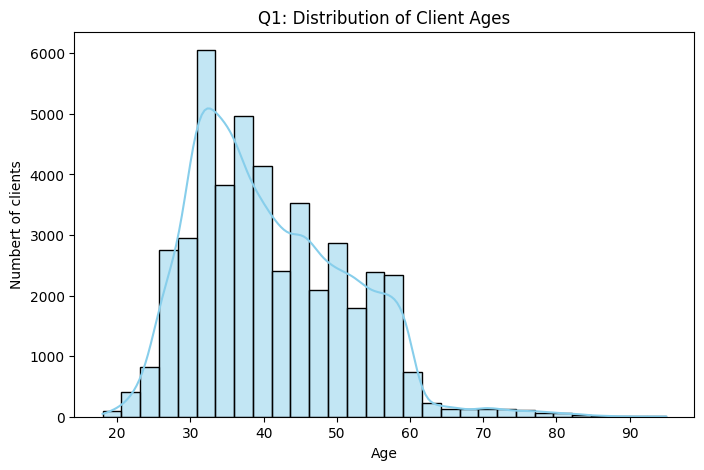


Q1: The age distribution of the clients is slightly right-skewed. The majority of the targeted clients fall between the ages of 30 and 50, indicating that the bank is primarily focusing its marketing efforts on middle-aged, working professionals.


In [42]:
#Q1
print("--- Q1: Age Stats ---")
print("Youngest client:", df['age'].min())
print("Oldest client:", df['age'].max())
print("Average (mean) age:", round(df['age'].mean(),1))

plt.figure(figsize=(8,5))
sns.histplot(df['age'],bins=30,  kde=True,color='skyblue')
plt.title('Q1: Distribution of Client Ages')
plt.xlabel('Age')
plt.ylabel('Numbert of clients')
plt.show()

print("""\nQ1: The age distribution of the clients is slightly right-skewed. The majority of the targeted clients fall between the ages of 30 and 50, indicating that the bank is primarily focusing its marketing efforts on middle-aged, working professionals.""")

--- Q2: Job Type Percentages ---
job
blue-collar      21.5
management       20.9
technician       16.8
admin.           11.4
services          9.2
retired           5.0
self-employed     3.5
entrepreneur      3.3
unemployed        2.9
housemaid         2.7
student           2.1
unknown           0.6
Name: proportion, dtype: float64


/tmp/ipykernel_3024/2450500865.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df , y='job', order=df['job'].value_counts().index, palette = 'viridis')


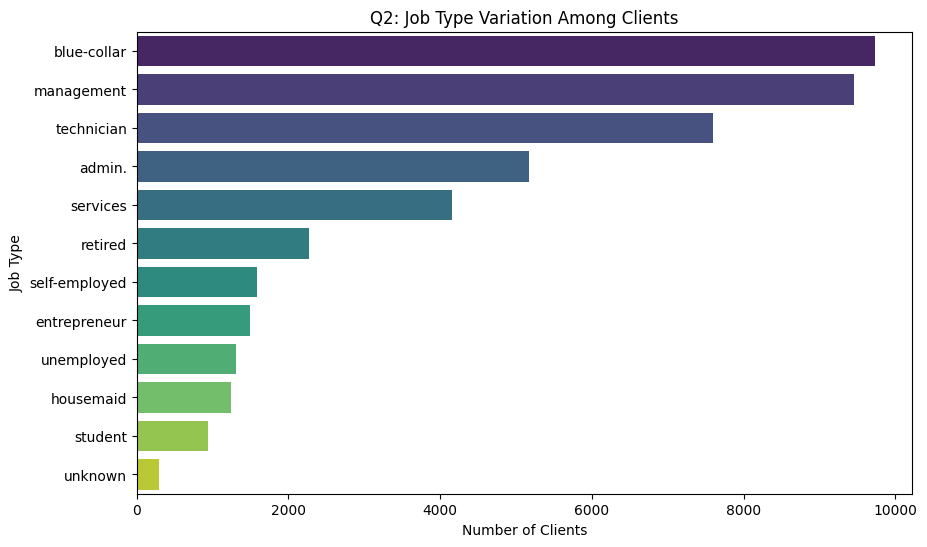


Q2: The clients belong to a wide variety of occupations, but the most common job types are 'blue-collar', 'management', and 'technician'. This shows the campaign is heavily reaching out to the working class and corporate professionals.


In [43]:
# 1. Calculate and print the exact percentages for each job
print("--- Q2: Job Type Percentages ---")
job_percentages = df['job'].value_counts(normalize=True)*100
print(round(job_percentages,1))

#2 plot the bar chart
plt.figure(figsize=(10,6))
sns.countplot(data=df , y='job', order=df['job'].value_counts().index, palette = 'viridis')
plt.title('Q2: Job Type Variation Among Clients')
plt.xlabel('Number of Clients')
plt.ylabel('Job Type')
plt.show()

print("""\nQ2: The clients belong to a wide variety of occupations, but the most common job types are 'blue-collar', 'management', and 'technician'. This shows the campaign is heavily reaching out to the working class and corporate professionals.""")

---Marital Status Percentage---
marital
married     60.2
single      28.3
divorced    11.5
unknown      0.0
Name: proportion, dtype: float64


/tmp/ipykernel_3024/3480340833.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df,x='marital', order=df['marital'].value_counts().index, palette='pastel')


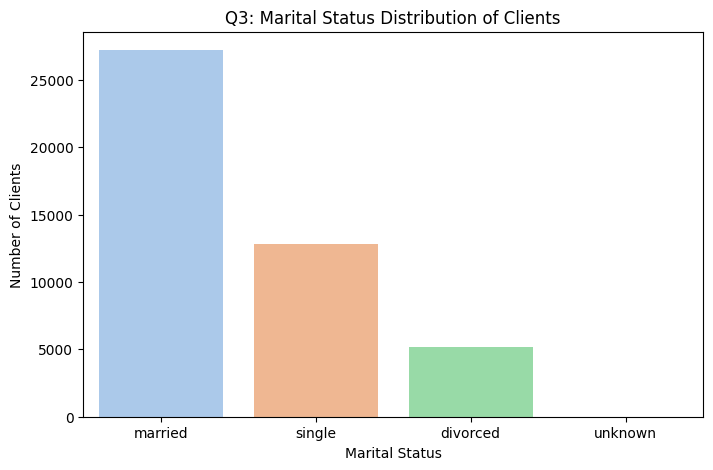


Q3: The majority of the clients contacted during this campaign are married. Single and divorced clients make up a significantly smaller portion of the dataset.


In [44]:
#Q3 - 'Q3: Marital Status Distribution of Clients'
#Print marital_percentage
print("---Marital Status Percentage---")
marital_percentages = df['marital'].value_counts(normalize=True)*100
print(round(marital_percentages,1))

#2.Plot the Bar Chart
plt.figure(figsize=(8,5))
sns.countplot(data=df,x='marital', order=df['marital'].value_counts().index, palette='pastel')
plt.title('Q3: Marital Status Distribution of Clients')
plt.xlabel('Marital Status')
plt.ylabel('Number of Clients')
plt.show()

print("""\nQ3: The majority of the clients contacted during this campaign are married. Single and divorced clients make up a significantly smaller portion of the dataset.""")

--- Q4: Education Level Percentages ---
education
secondary    51.3
tertiary     29.4
primary      15.2
unknown       4.1
Name: proportion, dtype: float64


/tmp/ipykernel_3024/1580500063.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df , x='education', order=df['education'].value_counts().index , palette='Set2' )


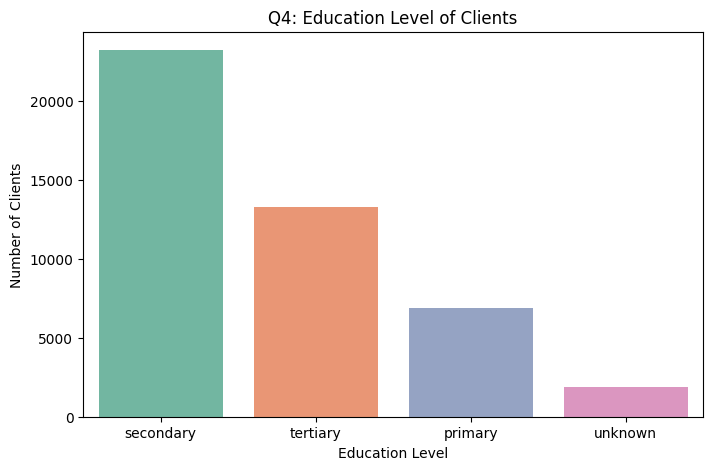


Q4: The highest level of education for the majority of clients is 'secondary' (high school), followed closely by 'tertiary' (college/university). Very few clients have only a primary level of education.


In [45]:
#Q4: Education Level of Clients
#Find percentage of education level of clients
print("--- Q4: Education Level Percentages ---")
education_percentage = df['education'].value_counts(normalize = True) * 100
print(round(education_percentage,1))

# 2. Plot the Bar Chart
plt.figure(figsize=(8,5))
sns.countplot(data=df , x='education', order=df['education'].value_counts().index , palette='Set2' )
plt.title('Q4: Education Level of Clients')
plt.xlabel('Education Level')
plt.ylabel('Number of Clients')
plt.show()

print("""\nQ4: The highest level of education for the majority of clients is 'secondary' (high school), followed closely by 'tertiary' (college/university). Very few clients have only a primary level of education.""")

--- Q5: Credit Default Proportions ---
default
no     98.2
yes     1.8
Name: proportion, dtype: float64


/tmp/ipykernel_3024/2448423082.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x='default',order = df['default'].value_counts().index,palette = 'Set1' )


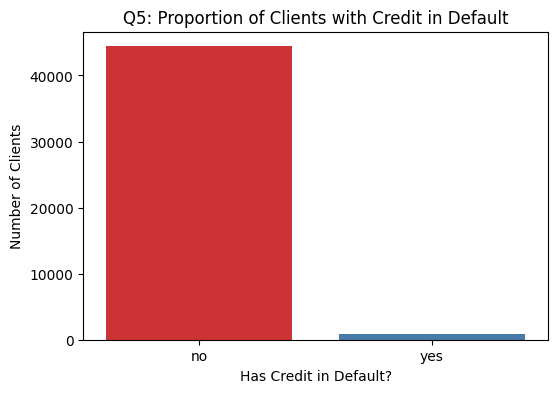


Q5: The data is heavily imbalanced regarding credit defaults. An overwhelming majority of the clients do not have credit in default, which makes sense as the bank likely filters out high-risk individuals before calling them for investment opportunities.


In [46]:
#Q5: Proportion of Clients with Credit in Default
print("--- Q5: Credit Default Proportions ---")
default_percentages = df['default'].value_counts(normalize=True)*100
print(round(default_percentages,1))

# 2. Plot the Bar Chart
plt.figure(figsize=(6,4))
sns.countplot(data=df, x='default',order = df['default'].value_counts().index,palette = 'Set1' )
plt.title('Q5: Proportion of Clients with Credit in Default')
plt.xlabel('Has Credit in Default?')
plt.ylabel('Number of Clients')
plt.show()

print("""\nQ5: The data is heavily imbalanced regarding credit defaults. An overwhelming majority of the clients do not have credit in default, which makes sense as the bank likely filters out high-risk individuals before calling them for investment opportunities.""")

--- Q6: Average Yearly Balance Stats ---
Lowest Balance (In Debt): -8019
Highest Balance: 102127
Average(Mean) 1362.28
Median (True Middle): 448.5


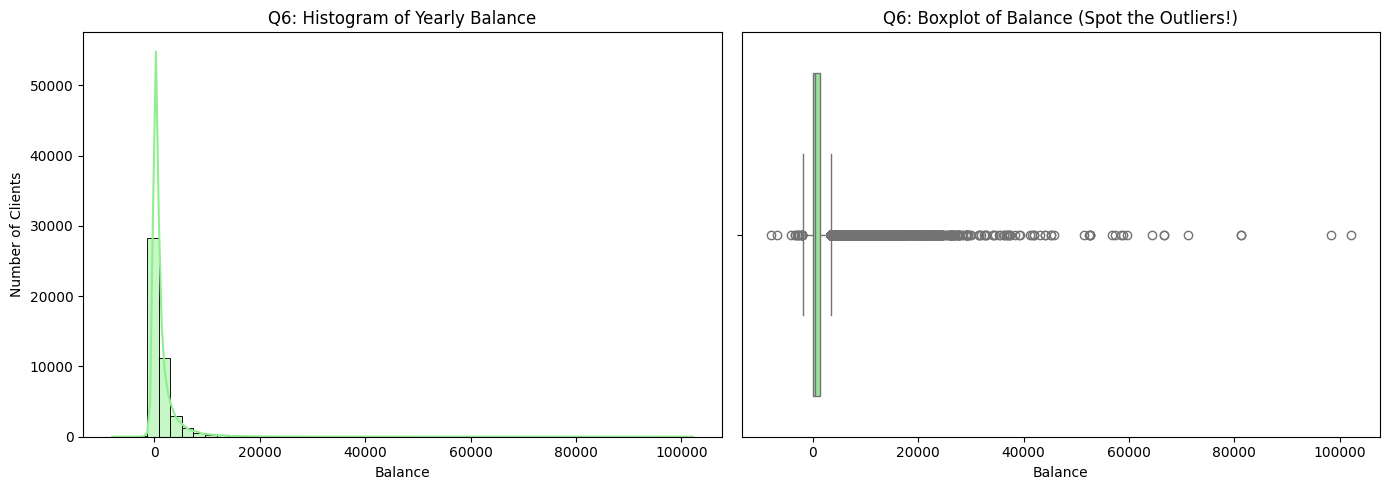


Q6: The distribution of yearly balances is highly right-skewed. Most clients maintain relatively low bank balances, but there is a long tail of extreme outliers representing a few very wealthy individuals with massive balances.


In [47]:
print("--- Q6: Average Yearly Balance Stats ---")
print("Lowest Balance (In Debt):", df['balance'].min())
print("Highest Balance:", df['balance'].max())
print("Average(Mean)", round(df['balance'].mean(),2))
print("Median (True Middle):", df['balance'].median())

# 2. Plot the Histogram AND Boxplot side-by-side
fig,axes = plt.subplots(1,2,figsize=(14,5))

#Histogram
sns.histplot(df['balance'], bins=50, kde=True,ax=axes[0], color='lightgreen')
axes[0].set_title('Q6: Histogram of Yearly Balance')
axes[0].set_xlabel('Balance')
axes[0].set_ylabel('Number of Clients')

#Boxplot
sns.boxplot(x=df['balance'], ax=axes[1], color='lightgreen')
axes[1].set_title('Q6: Boxplot of Balance (Spot the Outliers!)')
axes[1].set_xlabel('Balance')

plt.tight_layout()
plt.show()
print("""\nQ6: The distribution of yearly balances is highly right-skewed. Most clients maintain relatively low bank balances, but there is a long tail of extreme outliers representing a few very wealthy individuals with massive balances.""")

--- Q7: Housing Loans ---
housing
yes    55.6
no     44.4
Name: proportion, dtype: float64

--- Q8: Personal Loans ---
loan
no     84.0
yes    16.0
Name: proportion, dtype: float64


/tmp/ipykernel_3024/1982151561.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data = df, x='housing', order=df['housing'].value_counts().index, ax=axes[0], palette='Blues')
/tmp/ipykernel_3024/1982151561.py:19: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data = df, x= 'loan', order=df['loan'].value_counts().index, ax=axes[1], palette="Oranges")


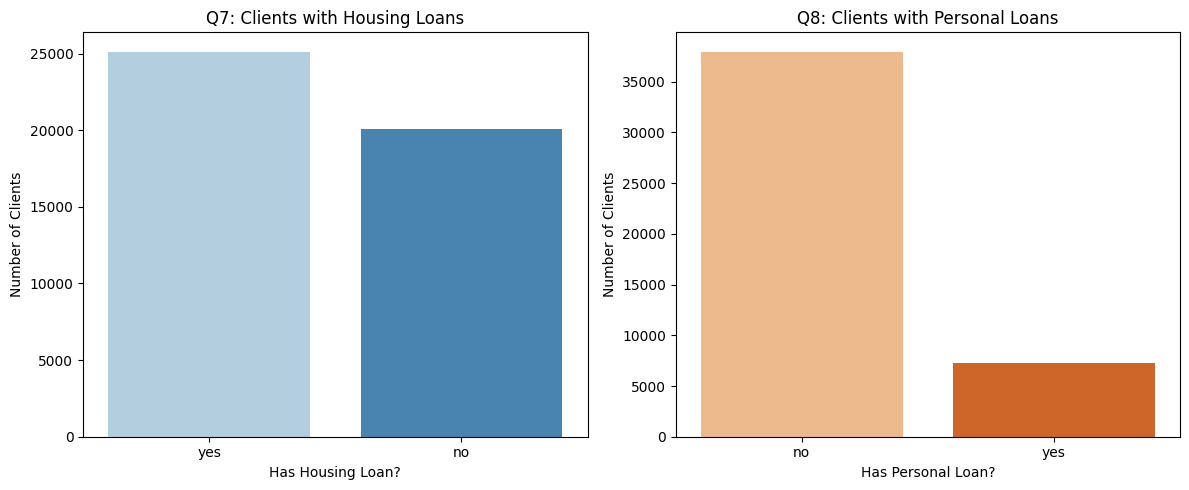


Q7: A slight majority of the clients contacted currently have an active housing loan (mortgage). This indicates that the bank's target audience largely consists of homeowners.

Q8: Unlike housing loans, the vast majority of clients do not have an active personal loan.


In [48]:
# 1. Print the exact percentages for Housing Loans
print("--- Q7: Housing Loans ---")
housing_percents = df['housing'].value_counts(normalize=True)*100
print(round(housing_percents,1))
# 2. Print the exact percentages for Personal Loans
print("\n--- Q8: Personal Loans ---")
loan_percentages = df['loan'].value_counts(normalize=True) * 100
print(loan_percentages.round(1))

fig , axes = plt.subplots(1,2, figsize=(12,5))

#Q7 Chart
sns.countplot(data = df, x='housing', order=df['housing'].value_counts().index, ax=axes[0], palette='Blues')
axes[0].set_title('Q7: Clients with Housing Loans')
axes[0].set_xlabel('Has Housing Loan?')
axes[0].set_ylabel('Number of Clients')

# Q8 Chart
sns.countplot(data = df, x= 'loan', order=df['loan'].value_counts().index, ax=axes[1], palette="Oranges")
axes[1].set_title('Q8: Clients with Personal Loans')
axes[1].set_xlabel('Has Personal Loan?')
axes[1].set_ylabel('Number of Clients')

plt.tight_layout()
plt.show()

print("""\nQ7: A slight majority of the clients contacted currently have an active housing loan (mortgage). This indicates that the bank's target audience largely consists of homeowners.""")
print("""\nQ8: Unlike housing loans, the vast majority of clients do not have an active personal loan.""")

--- Q9: Communication Types ---
contact
cellular     64.8
unknown      28.8
telephone     6.4
Name: proportion, dtype: float64


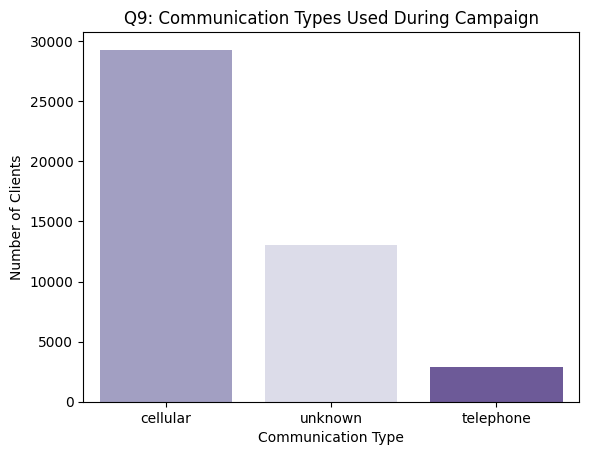


The preferred and most successful method of communication by far is 'cellular' (mobile phones). Reaching clients via traditional landlines ('telephone') is much less common.


In [49]:
#Q9: Communication Types Used During Campaign

print("--- Q9: Communication Types ---")
comm_percentages = df['contact'].value_counts(normalize=True)*100
print(round(comm_percentages,1))

#Plot bar chart
sns.countplot(data=df, x='contact', hue='contact', order=df['contact'].value_counts().index, palette='Purples', legend=False)
plt.title('Q9: Communication Types Used During Campaign')
plt.xlabel('Communication Type')
plt.ylabel('Number of Clients')
plt.show()
print("""\nThe preferred and most successful method of communication by far is 'cellular' (mobile phones). Reaching clients via traditional landlines ('telephone') is much less common.""")

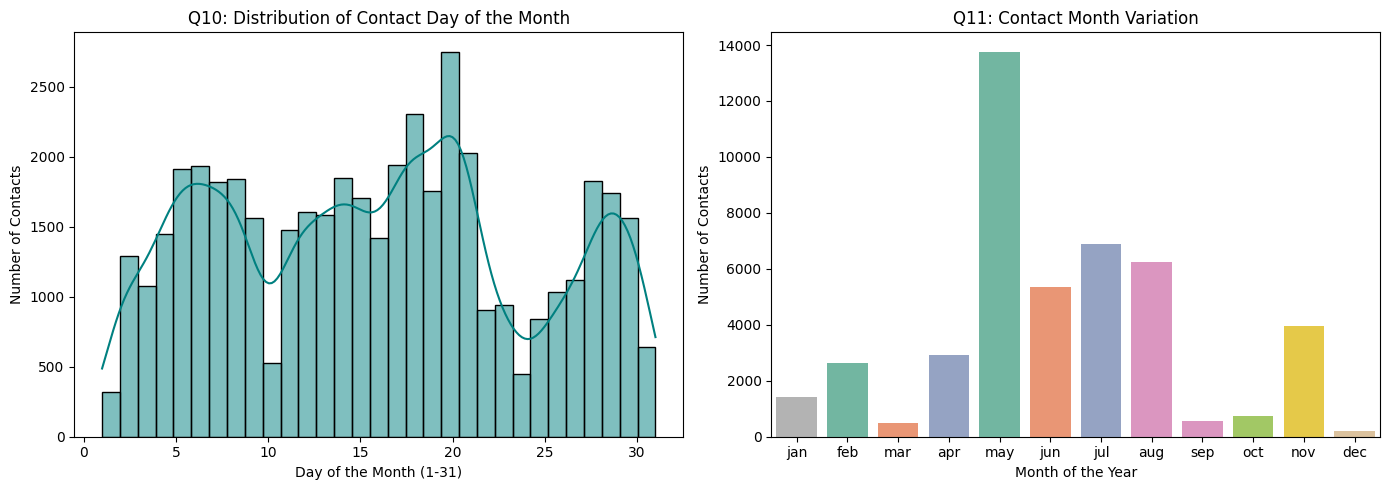


Q10: The contacts are spread out across all days of the month, but there are noticeable spikes in campaign activity during the middle of the month (around the 15th to the 20th).

Q11: 'May' is by far the busiest month for this marketing campaign, seeing more than double the activity of most other months. Conversely, the winter months like December and January saw very little campaign activity.


In [50]:
#Q10 Chart: Histogram for the Day (Numerical)
fig,axes = plt.subplots(1,2,figsize=(14,5))
sns.histplot(data=df ,x='day', bins = 31,kde=True, ax=axes[0],color='teal')
axes[0].set_title('Q10: Distribution of Contact Day of the Month')
axes[0].set_xlabel('Day of the Month (1-31)')
axes[0].set_ylabel('Number of Contacts')

# Q11 Chart: Bar Chart for the Month (Categorical)
month_order = ['jan', 'feb', 'mar', 'apr', 'may', 'jun', 'jul', 'aug', 'sep', 'oct', 'nov', 'dec']
sns.countplot(data=df, x='month', hue='month', order=month_order,ax=axes[1],palette='Set2', legend=False)
axes[1].set_title('Q11: Contact Month Variation')
axes[1].set_xlabel('Month of the Year')
axes[1].set_ylabel('Number of Contacts')

plt.tight_layout()
plt.show()
print("""\nQ10: The contacts are spread out across all days of the month, but there are noticeable spikes in campaign activity during the middle of the month (around the 15th to the 20th).""")
print("""\nQ11: 'May' is by far the busiest month for this marketing campaign, seeing more than double the activity of most other months. Conversely, the winter months like December and January saw very little campaign activity.""")

In [51]:
df['pdays'].head(-1)

,pdays
0,-1
1,-1
2,-1
3,-1
4,-1
...,...
45210,188
45211,-1
45212,187
45213,184


--- Q12: Call Duration Stats ---
Shortest Call: 0 seconds
Longest Call: 4918 seconds
Average (Mean) Call: 258.2 seconds
Median Call: 180.0 seconds


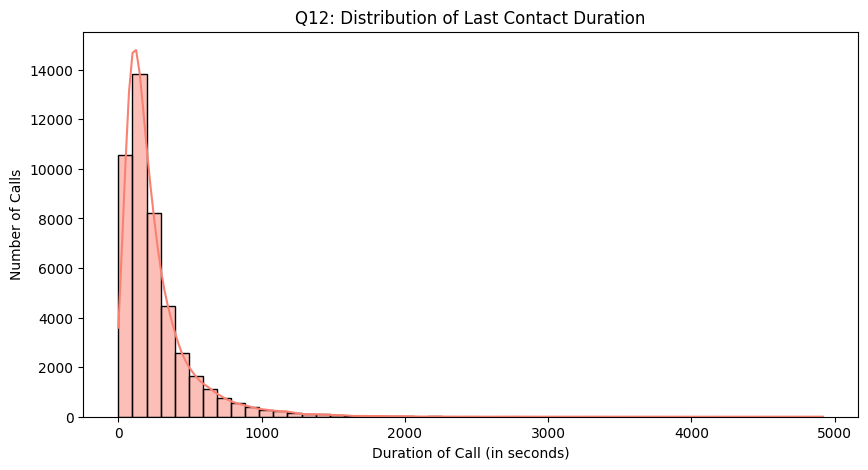


The distribution of the last contact duration is highly right-skewed. The vast majority of phone calls are relatively short, with the median call lasting only 180 seconds (3 minutes). However, there is a long tail indicating a small number of extremely long conversations, with the maximum call duration reaching nearly 4,918 seconds (over 1 hour and 20 minutes!).


In [52]:
#Q12: Distribution of Last Contact Duration
# 1. Print the exact stats
print("--- Q12: Call Duration Stats ---")
print("Shortest Call:",df['duration'].min(),"seconds")
print("Longest Call:", df['duration'].max(),"seconds")
print("Average (Mean) Call:", round(df['duration'].mean(),1),"seconds")
print("Median Call:", df['duration'].median(), "seconds")

#Plot The Histogram
plt.figure(figsize=(10,5))
sns.histplot(data=df,x='duration',bins=50,kde=True,color='salmon')
plt.title('Q12: Distribution of Last Contact Duration')
plt.xlabel('Duration of Call (in seconds)')
plt.ylabel('Number of Calls')
plt.show()
print("\nThe distribution of the last contact duration is highly right-skewed. The vast majority of phone calls are relatively short, with the median call lasting only 180 seconds (3 minutes). However, there is a long tail indicating a small number of extremely long conversations, with the maximum call duration reaching nearly 4,918 seconds (over 1 hour and 20 minutes!).")

--Q13 Contacts performed during campaign stats--
Lowest Number 1
Highest Number 63
Mean Number 2.76
Median Number 2.0

Histogram


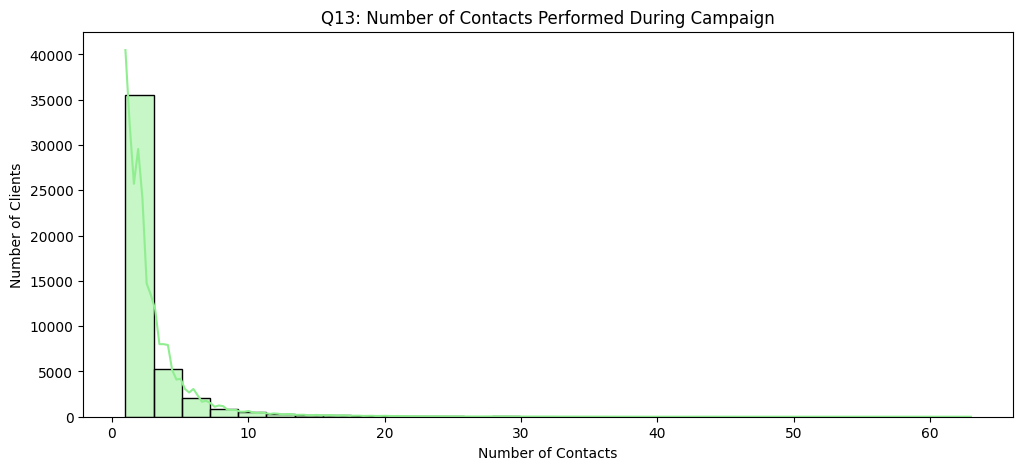


Most clients were only contacted 1, 2, or 3 times during this specific campaign. However, the distribution is heavily right-skewed due to a few extreme outliers where some clients were called aggressively (upwards of 50+ times).


In [53]:
#Q13-	How many contacts were performed during the campaign for each client?
print("--Q13 Contacts performed during campaign stats--")
print("Lowest Number", df['campaign'].min())
print("Highest Number", df['campaign'].max())
print("Mean Number", df['campaign'].mean().round(2))
print("Median Number", df['campaign'].median())

print("\nHistogram")
plt.figure(figsize=(12,5))
sns.histplot(data=df,x='campaign',bins=30,kde=True,color='lightgreen')
plt.title('Q13: Number of Contacts Performed During Campaign')
plt.xlabel('Number of Contacts')
plt.ylabel('Number of Clients')
plt.show()

print("\nMost clients were only contacted 1, 2, or 3 times during this specific campaign. However, the distribution is heavily right-skewed due to a few extreme outliers where some clients were called aggressively (upwards of 50+ times).")

===Client was last contacted from a previous campaign stats===
Lowest pdays -1
Highest pdays 871
Mean pdays 40.2
Median pdays -1.0

Histogram


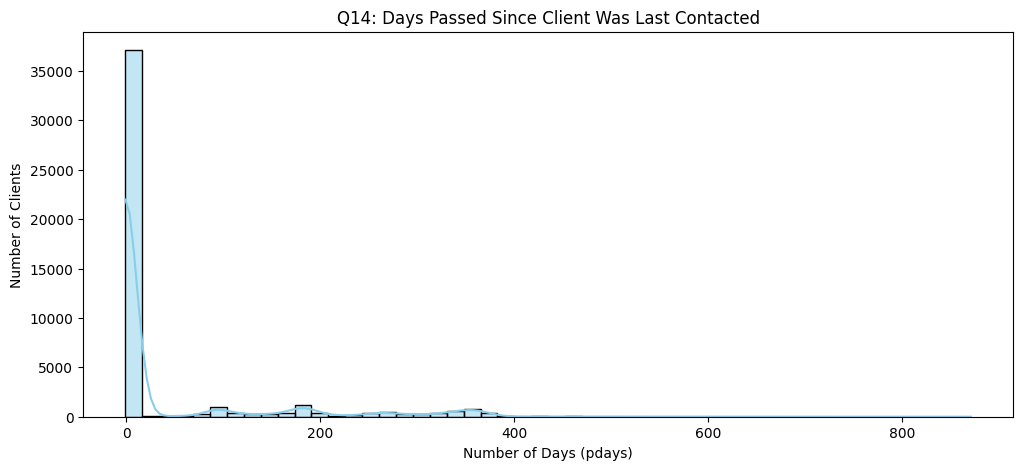

The pdays variable shows how many days passed since a client was contacted in a previous campaign. The histogram reveals a massive, overwhelming spike at -1. In this dataset, -1 means the client was never previously contacted. Because the vast majority of people in this campaign are new contacts, the median is exactly -1. For the small minority of clients who were contacted before, the days passed usually range from 100 to 400 days.


In [54]:
#Q14--	What is the distribution of the number of days passed since the client was last contacted from a previous campaign?

print("===Client was last contacted from a previous campaign stats===")
print("Lowest pdays", df['pdays'].min())
print("Highest pdays", df['pdays'].max())
print("Mean pdays",df['pdays'].mean().round(2))
print("Median pdays",df['pdays'].median())

print("\nHistogram")
# 2. Histogram
plt.figure(figsize=(12, 5))
sns.histplot(data=df, x='pdays', bins=50, kde=True, color='skyblue')
plt.title('Q14: Days Passed Since Client Was Last Contacted')
plt.xlabel('Number of Days (pdays)')
plt.ylabel('Number of Clients')
plt.show()

print("The pdays variable shows how many days passed since a client was contacted in a previous campaign. The histogram reveals a massive, overwhelming spike at -1. In this dataset, -1 means the client was never previously contacted. Because the vast majority of people in this campaign are new contacts, the median is exactly -1. For the small minority of clients who were contacted before, the days passed usually range from 100 to 400 days.")


=== Q15: Contacts Performed Before Current Campaign Stats ===
Lowest previous contacts: 0
Highest previous contacts: 275
Mean previous contacts: 0.58
Median previous contacts: 0.0

Histogram


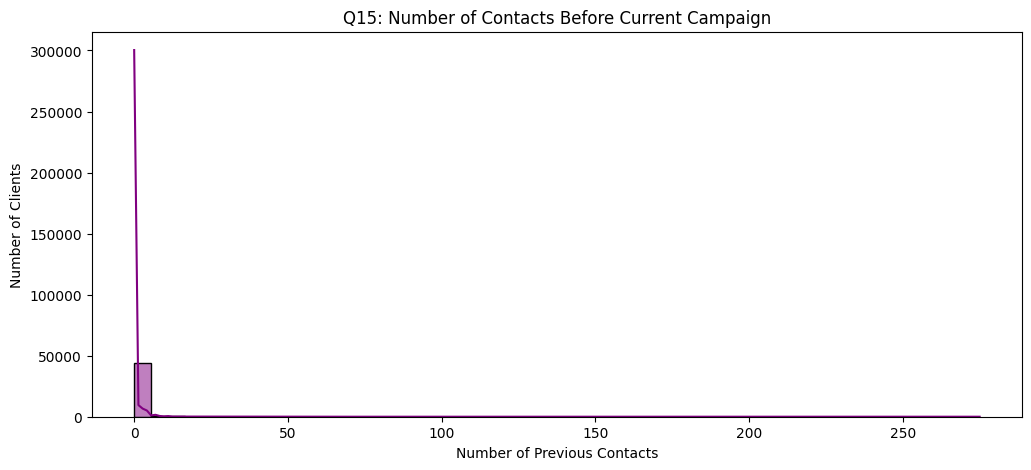


How many contacts were performed before the current campaign for each client?
Write-up: Similar to pdays, this distribution is heavily right-skewed with a massive spike at 0. 
This confirms again that the overwhelming majority of clients had exactly zero previous contacts 
prior to this current campaign.


In [55]:
#Q15--	-	How many contacts were performed before the current campaign for each client?
print("=== Q15: Contacts Performed Before Current Campaign Stats ===")
print("Lowest previous contacts:", df['previous'].min())
print("Highest previous contacts:", df['previous'].max())
print("Mean previous contacts:", df['previous'].mean().round(2))
print("Median previous contacts:", df['previous'].median())

print("\nHistogram")
# 2. Histogram
plt.figure(figsize=(12, 5))
sns.histplot(data=df, x='previous', bins=50, kde=True, color='purple')
plt.title('Q15: Number of Contacts Before Current Campaign')
plt.xlabel('Number of Previous Contacts')
plt.ylabel('Number of Clients')
plt.show()

print("""\nHow many contacts were performed before the current campaign for each client?
Write-up: Similar to pdays, this distribution is heavily right-skewed with a massive spike at 0.
This confirms again that the overwhelming majority of clients had exactly zero previous contacts
prior to this current campaign.""")

=== Q16: Previous Campaign Outcome ===
poutcome
unknown    81.7
failure    10.8
other       4.1
success     3.3
Name: proportion, dtype: float64


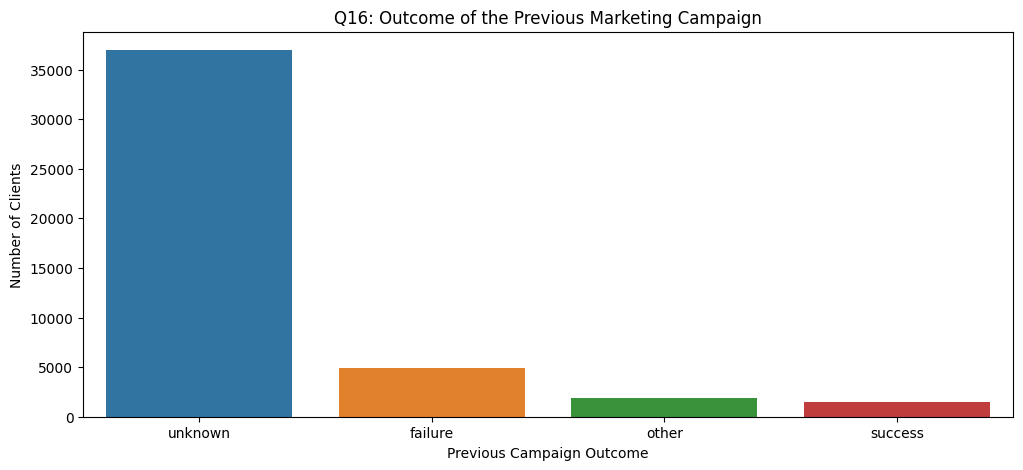

The overwhelming majority of previous campaign outcomes are categorized as 'unknown' (over 80%). This perfectly aligns with our findings from the previous questions, which revealed that most of these clients are brand new leads who were never contacted prior to the current campaign. For the small fraction of clients who were contacted previously, the most common known outcome was 'failure', with a much smaller percentage resulting in a 'success'.


In [56]:
print("=== Q16: Previous Campaign Outcome ===")
percentage_poutcome = df['poutcome'].value_counts(normalize=True)*100
print(percentage_poutcome.round(1))
plt.figure(figsize=(12,5))
sns.countplot(data=df , x='poutcome',hue='poutcome', order=df['poutcome'].value_counts().index)
plt.title('Q16: Outcome of the Previous Marketing Campaign')
plt.xlabel('Previous Campaign Outcome')
plt.ylabel('Number of Clients')
plt.show()

print("The overwhelming majority of previous campaign outcomes are categorized as 'unknown' (over 80%). This perfectly aligns with our findings from the previous questions, which revealed that most of these clients are brand new leads who were never contacted prior to the current campaign. For the small fraction of clients who were contacted previously, the most common known outcome was 'failure', with a much smaller percentage resulting in a 'success'.")

=== Q17: Term Deposit Subscription (Target Variable) ===
y
no     88.3
yes    11.7
Name: proportion, dtype: float64


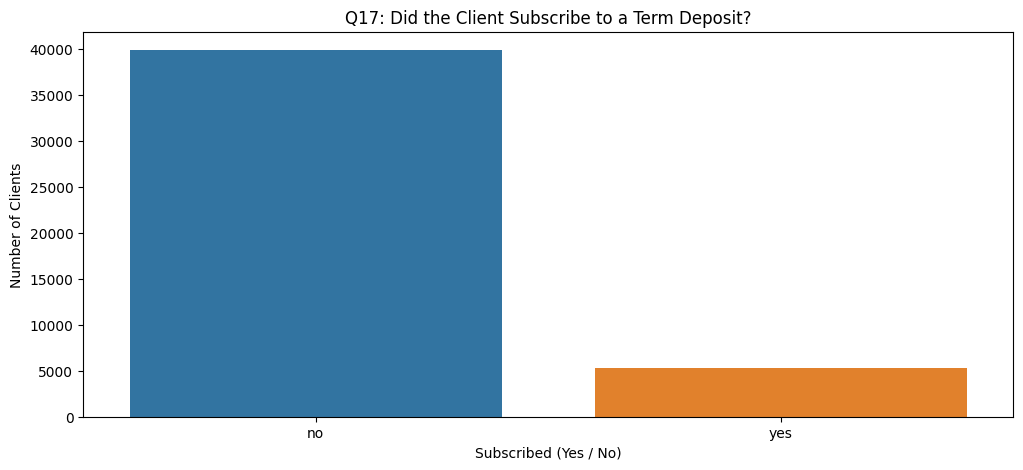

The y variable represents the ultimate success of the campaign: whether the client subscribed to a term deposit. The data reveals that the campaign has a relatively low success rate, which is typical for telemarketing. The dataset is highly imbalanced, with the vast majority of clients (approx. 88.3%) declining the offer ('no'), while only a small fraction (approx. 11.7%) actually subscribed ('yes').


In [57]:
print("=== Q17: Term Deposit Subscription (Target Variable) ===")
percentage_y = df['y'].value_counts(normalize=True) * 100
print(percentage_y.round(1))

plt.figure(figsize=(12,5))
sns.countplot(data=df ,x='y',hue='y',order=df['y'].value_counts().index)
plt.title('Q17: Did the Client Subscribe to a Term Deposit?')
plt.xlabel('Subscribed (Yes / No)')
plt.ylabel('Number of Clients')

plt.show()
print("The y variable represents the ultimate success of the campaign: whether the client subscribed to a term deposit. The data reveals that the campaign has a relatively low success rate, which is typical for telemarketing. The dataset is highly imbalanced, with the vast majority of clients (approx. 88.3%) declining the offer ('no'), while only a small fraction (approx. 11.7%) actually subscribed ('yes').")

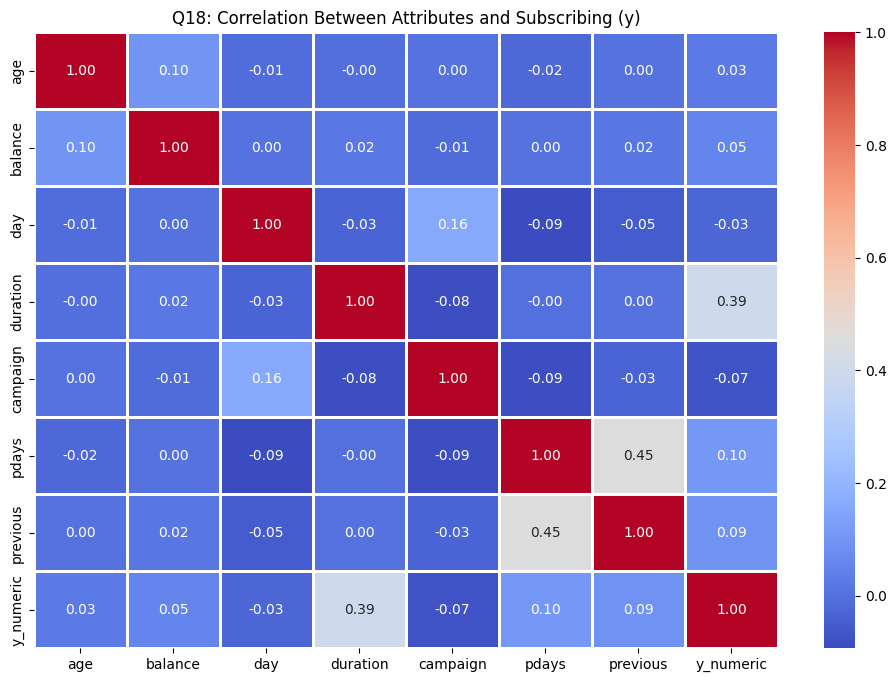


--- Correlation with Target Variable (Subscribing) ---
y_numeric    1.000000
duration     0.394387
pdays        0.103699
previous     0.093576
balance      0.052821
age          0.025648
day         -0.028307
campaign    -0.073294
Name: y_numeric, dtype: float64

To determine the correlations between different attributes and the likelihood of a client subscribing, we converted the target variable (y) into a numeric format (1 for yes, 0 for no) and generated a correlation heatmap. The analysis reveals that most numerical attributes—such as age, balance, and campaign (number of calls)—have virtually no correlation with the success of the campaign, scoring very close to 0.
However, there is one significant exception: duration. The duration of the last contact has the strongest positive correlation with a successful subscription. This indicates a clear business insight: the longer a client remains on the phone during the marketing call, the significantly higher the likelihood that they wi

In [58]:
df['y_numeric']= df['y'].map({'yes':1, 'no':0})

numeric_df = df.select_dtypes(include=['int64','float64'])

corr_matrix= numeric_df.corr()

plt.figure(figsize=(12, 8))
# annot=True puts the numbers in the boxes, cmap='coolwarm' makes positives red and negatives blue
sns.heatmap(corr_matrix, annot=True, fmt=".2f", cmap='coolwarm', linewidths=1)
plt.title('Q18: Correlation Between Attributes and Subscribing (y)')
plt.show()

print("\n--- Correlation with Target Variable (Subscribing) ---")
print(corr_matrix['y_numeric'].sort_values(ascending=False))

print("""\nTo determine the correlations between different attributes and the likelihood of a client subscribing, we converted the target variable (y) into a numeric format (1 for yes, 0 for no) and generated a correlation heatmap. The analysis reveals that most numerical attributes—such as age, balance, and campaign (number of calls)—have virtually no correlation with the success of the campaign, scoring very close to 0.
However, there is one significant exception: duration. The duration of the last contact has the strongest positive correlation with a successful subscription. This indicates a clear business insight: the longer a client remains on the phone during the marketing call, the significantly higher the likelihood that they will subscribe to the term deposit.""")